In [3]:
!pip install pytesseract

In [4]:
import pytesseract


In [5]:
import shutil

In [6]:
from PIL import Image

In [7]:
tesseract_path = shutil.which("tesseract")
print("tesseract path detected as :", tesseract_path)

tesseract path detected as : C:\Program Files\Tesseract-OCR\tesseract.EXE


In [8]:
!tesseract -version

Usage:
  tesseract --help | --help-extra | --version
  tesseract --list-langs
  tesseract imagename outputbase [options...] [configfile...]

OCR options:
  -l LANG[+LANG]        Specify language(s) used for OCR.
NOTE: These options must occur before any configfile.

Single options:
  --help                Show this help message.
  --help-extra          Show extra help for advanced users.
  --version             Show version information.
  --list-langs          List available languages for tesseract engine.


In [11]:
import subprocess, sys 

In [12]:
import subprocess, sys

packages = [
    'pytesseract',
    'Pillow',
    'opencv-python-headless',
    'pandas',
    'numpy',
    'folium',
    'matplotlib',
    'tqdm'
] 

In [13]:
for pkg in packages:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        capture_output=True, text=True
    )
    status = '✅' if result.returncode == 0 else '❌'
    print(f"{status} {pkg}") 

✅ pytesseract
✅ Pillow
✅ opencv-python-headless
✅ pandas
✅ numpy
✅ folium
✅ matplotlib
✅ tqdm


In [14]:
import os
import re
import subprocess
import numpy as np
import pandas as pd
import pytesseract
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import folium
import warnings

from PIL import Image, ImageEnhance
from math import radians, cos, sin, asin, sqrt
from tqdm.notebook import tqdm
from IPython.display import display, HTML, IFrame

warnings.filterwarnings('ignore')
print('✅ All libraries imported successfully') 

✅ All libraries imported successfully


In [16]:
VIDEO_PATH = 'Eng_clg_60504PMByGPSMapCamera.mp4' 

In [17]:
OUTPUT_CSV        = 'gps_track.csv'
FRAMES_DIR        = 'frames_temp'
FPS_EXTRACT       = 1  # 1 frame per second  (increase for finer resolution)
CROP_BOTTOM_THIRD = True  

In [18]:
os.makedirs(FRAMES_DIR, exist_ok=True)

In [19]:
if os.path.exists(VIDEO_PATH):
    size_mb = os.path.getsize(VIDEO_PATH) / 1024 / 1024
    print(f'✅ Video found: {VIDEO_PATH}  ({size_mb:.1f} MB)')
else:
    print(f'❌ Video NOT found at: {VIDEO_PATH}')
    print('   → Update VIDEO_PATH above and re-run this cell.') 

✅ Video found: Eng_clg_60504PMByGPSMapCamera.mp4  (127.2 MB)


In [20]:
import cv2 

In [21]:
cap = cv2.VideoCapture(VIDEO_PATH) 

In [22]:
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
native_fps   = cap.get(cv2.CAP_PROP_FPS)
duration_s   = total_frames / native_fps
width        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) 

In [23]:
cap.release() 

In [24]:
expected_frames = int(duration_s * FPS_EXTRACT) 

In [25]:
print('━' * 45)
print(f'  Resolution   : {width} × {height} px')
print(f'  Native FPS   : {native_fps:.2f}')
print(f'  Total frames : {total_frames:,}')
print(f'  Duration     : {duration_s:.1f} s  ({duration_s/60:.2f} min)')
print('━' * 45)
print(f'  Extract rate : {FPS_EXTRACT} fps')
print(f'  → ~{expected_frames} frames will be extracted')
print('━' * 45) 

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Resolution   : 1088 × 1440 px
  Native FPS   : 29.17
  Total frames : 2,022
  Duration     : 69.3 s  (1.16 min)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Extract rate : 1 fps
  → ~69 frames will be extracted
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [26]:
vf_filter = f'fps={FPS_EXTRACT},crop=iw:ih/3:0:2*ih/3'


In [27]:
cmd = [
    'ffmpeg',
    '-i', VIDEO_PATH,
    '-vf', vf_filter,
    os.path.join(FRAMES_DIR, 'frame_%04d.jpg'),
    '-y',                 # overwrite if exists
    '-loglevel', 'error'  # suppress verbose output
] 

In [28]:
print(f'⏳ Running ffmpeg...')
print(f'   Filter: {vf_filter}') 

⏳ Running ffmpeg...
   Filter: fps=1,crop=iw:ih/3:0:2*ih/3


In [29]:
result = subprocess.run(cmd, capture_output=True, text=True)

In [30]:
if result.returncode != 0:
    print('❌ ffmpeg failed:')
    print(result.stderr)
else:
    extracted = len([f for f in os.listdir(FRAMES_DIR) if f.endswith('.jpg')])
    print(f'✅ Extracted {extracted} frames → {FRAMES_DIR}/') 

✅ Extracted 69 frames → frames_temp/


In [31]:
frame_files = sorted([f for f in os.listdir(FRAMES_DIR) if f.endswith('.jpg')]) 

In [32]:
sample_indices = [0, len(frame_files)//2, -1]
sample_labels  = ['First frame (t=1s)', 'Middle frame', 'Last frame'] 

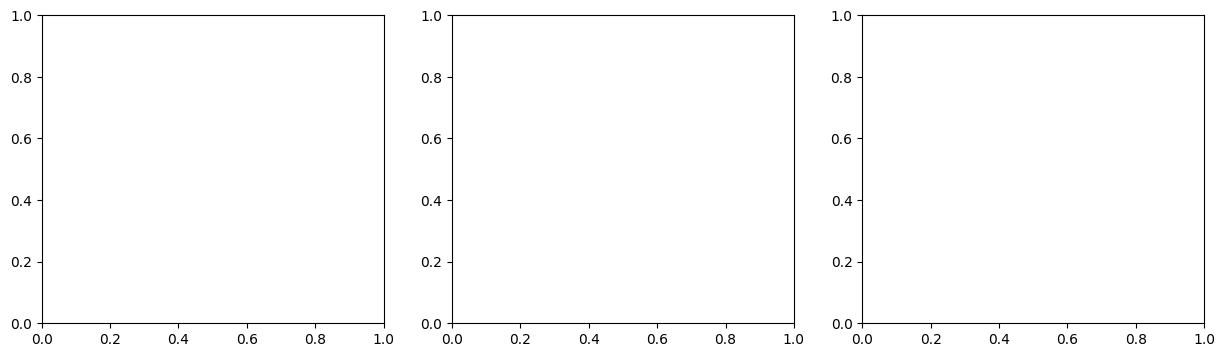

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4)) 

In [34]:
fig.patch.set_facecolor('#0d0f12') 

In [35]:
for ax, idx, label in zip(axes, sample_indices, sample_labels):
    img = Image.open(os.path.join(FRAMES_DIR, frame_files[idx]))
    ax.imshow(img)
    ax.set_title(label, color='white', fontsize=10, pad=6)
    ax.axis('off')

plt.suptitle('Extracted frames — GPS overlay region (bottom third)', 
             color='white', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()
print('→ Confirm you can see: Lat XX.XXXXXX° Long XX.XXXXXX° in the overlay text') 

<Figure size 640x480 with 0 Axes>

→ Confirm you can see: Lat XX.XXXXXX° Long XX.XXXXXX° in the overlay text


In [36]:
LAT_LON_RE = re.compile(
    r'[Ll]at\s*[:\-]?\s*([+\-]?\d{1,3}[.,]\d{4,})[°]?'
    r'\s*[Ll]o?n?g?\s*[:\-]?\s*([+\-]?\d{1,3}[.,]\d{4,})[°]?'
) 

In [37]:
FALLBACK_RE = re.compile(r'(\d{2}\.\d{4,})[°\s]+?([78]\d\.\d{4,})') 

In [38]:
DT_RE = re.compile(
    r'(?:\w+,\s*)?(\d{1,2}/\d{2}/\d{4}\s+\d{1,2}:\d{2}:\d{2}\s*[AP]M(?:\s*GMT\s*[+\-]\d{2}:\d{2})?)'
    , re.IGNORECASE
) 

In [39]:
records = [] 

In [40]:
for i, fname in enumerate(tqdm(frame_files, desc='🔍 OCR frames')):
    path   = os.path.join(FRAMES_DIR, fname)
    second = i + 1

    # ── 1. Load image
    img = Image.open(path)

    # ── 2. Enhance: boost contrast so white text pops on map background
    img = ImageEnhance.Contrast(img).enhance(2.0)

    # ── 3. Grayscale (Tesseract works best on single-channel images)
    img = img.convert('L')

    # ── 4. OCR
    #   --psm 6  = assume uniform block of text
    #   --oem 3  = use LSTM neural net engine
    text = pytesseract.image_to_string(img, config='--psm 6 --oem 3')

    # ── 5. Parse lat/lon
    lat, lon = None, None
    m = LAT_LON_RE.search(text)
    if m:
        lat = float(m.group(1).replace(',', '.'))
        lon = float(m.group(2).replace(',', '.'))
    else:
        m2 = FALLBACK_RE.search(text)
        if m2:
            lat = float(m2.group(1))
            lon = float(m2.group(2))

    # ── 6. Parse datetime
    dt_str = ''
    dm = DT_RE.search(text)
    if dm:
        dt_str = dm.group(1).strip()

    records.append({
        'second'       : second,
        'latitude'     : lat,
        'longitude'    : lon,
        'datetime_IST' : dt_str
    }) 

🔍 OCR frames:   0%|          | 0/69 [00:00<?, ?it/s]

In [41]:
df_raw = pd.DataFrame(records)
ok  = df_raw['latitude'].notna().sum()
bad = df_raw['latitude'].isna().sum()
print(f'\n✅ OCR complete')
print(f'   Successful readings : {ok}/{len(df_raw)} ({ok/len(df_raw)*100:.1f}%)')
print(f'   Failed (will interpolate): {bad}')
df_raw.head(5) 


✅ OCR complete
   Successful readings : 66/69 (95.7%)
   Failed (will interpolate): 3


,second,latitude,longitude,datetime_IST
0,1,26.913096,80.939474,20/05/2026 06:05:04 PM GMT +05:30
1,2,26.913117,80.939408,20/05/2026 06:05:05 PM GMT +05:30
2,3,26.913117,80.939408,
3,4,26.913128,80.939306,20/05/2026 06:05:07 PM GMT +05:30
4,5,26.913128,80.939306,20/05/2026 06:05:08 PM GMT +05:30


In [42]:
df = df_raw.copy() 

In [43]:
df['latitude']  = pd.to_numeric(df['latitude'],  errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce') 

In [44]:
LAT_MIN, LAT_MAX = 26.0, 28.0  

In [45]:
LON_MIN, LON_MAX = 80.0, 82.0   

In [46]:
df.loc[(df['latitude']  < LAT_MIN) | (df['latitude']  > LAT_MAX), 'latitude']  = np.nan
df.loc[(df['longitude'] < LON_MIN) | (df['longitude'] > LON_MAX), 'longitude'] = np.nan
 

In [47]:
n_missing_before = df['latitude'].isna().sum()
df['latitude']   = df['latitude'].interpolate(method='linear')
df['longitude']  = df['longitude'].interpolate(method='linear')
n_missing_after  = df['latitude'].isna().sum()
 

In [48]:
df['latitude']  = df['latitude'].round(6)
df['longitude'] = df['longitude'].round(6)
 

In [49]:
print('Cleaning complete')
print(f'  Missing before interpolation : {n_missing_before}')
print(f'  Missing after  interpolation : {n_missing_after}')
print(f'  Final rows                   : {len(df)}')
print()
print('Coordinate range:')
print(f'  Lat: {df["latitude"].min():.6f}  →  {df["latitude"].max():.6f}')
print(f'  Lon: {df["longitude"].min():.6f}  →  {df["longitude"].max():.6f}') 

Cleaning complete
  Missing before interpolation : 3
  Missing after  interpolation : 0
  Final rows                   : 69

Coordinate range:
  Lat: 26.913096  →  26.916897
  Lon: 80.937791  →  80.939474


In [50]:
def haversine_m(lat1, lon1, lat2, lon2):
    """Returns great-circle distance in metres between two WGS-84 coordinates."""
    R = 6_371_000  # Earth radius in metres
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    return 2 * R * asin(sqrt(a)) 

In [51]:
seg_dists = [0.0]  # first point has 0 distance
for i in range(1, len(df)):
    d = haversine_m(
        df['latitude'].iloc[i - 1], df['longitude'].iloc[i - 1],
        df['latitude'].iloc[i],     df['longitude'].iloc[i]
    )
    seg_dists.append(round(d, 3)) 

In [52]:
df['segment_dist_m']    = seg_dists
df['cumulative_dist_m'] = df['segment_dist_m'].cumsum().round(1)

total_m   = df['cumulative_dist_m'].iloc[-1]
total_km  = total_m / 1000
duration  = len(df)          # seconds
avg_kmh   = (total_km / duration) * 3600
max_seg   = df['segment_dist_m'].max() 

In [53]:
print('━' * 40)
print(f'  Total distance : {total_m:.1f} m  ({total_km:.3f} km)')
print(f'  Duration       : {duration} seconds')
print(f'  Avg speed      : {avg_kmh:.1f} km/h')
print(f'  Max step dist  : {max_seg:.2f} m')
print('━' * 40) 

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total distance : 540.7 m  (0.541 km)
  Duration       : 69 seconds
  Avg speed      : 28.2 km/h
  Max step dist  : 27.62 m
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [54]:
df.to_csv(OUTPUT_CSV, index=False) 

In [55]:
print(f'✅ Saved: {OUTPUT_CSV}')
print(f'   Rows    : {len(df)}')
print(f'   Columns : {list(df.columns)}')
print() 

✅ Saved: gps_track.csv
   Rows    : 69
   Columns : ['second', 'latitude', 'longitude', 'datetime_IST', 'segment_dist_m', 'cumulative_dist_m']



In [56]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.6f}'.format)
display(df.head(10)) 

,second,latitude,longitude,datetime_IST,segment_dist_m,cumulative_dist_m
0,1,26.913096,80.939474,20/05/2026 06:05:04 PM GMT +05:30,0.000000,0.000000
1,2,26.913117,80.939408,20/05/2026 06:05:05 PM GMT +05:30,6.948000,6.900000
2,3,26.913117,80.939408,,0.000000,6.900000
3,4,26.913128,80.939306,20/05/2026 06:05:07 PM GMT +05:30,10.187000,17.100000
4,5,26.913128,80.939306,20/05/2026 06:05:08 PM GMT +05:30,0.000000,17.100000
5,6,26.913136,80.939192,20/05/2026 06:05:10 PM GMT +05:30,11.338000,28.500000
6,7,26.913173,80.939010,20/05/2026 06:05:10 PM,18.509000,47.000000
7,8,26.913173,80.939010,,0.000000,47.000000
8,9,26.913173,80.939010,20/05/2026 06:05:12 PM GMT +05:30,0.000000,47.000000
9,10,26.913166,80.938862,20/05/2026 06:05:13 PM GMT +05:30,14.695000,61.700000


In [57]:
pd.set_option('display.max_rows', 100)
display(df[['second', 'latitude', 'longitude', 'datetime_IST', 'cumulative_dist_m']]) 

,second,latitude,longitude,datetime_IST,cumulative_dist_m
0,1,26.913096,80.939474,20/05/2026 06:05:04 PM GMT +05:30,0.000000
1,2,26.913117,80.939408,20/05/2026 06:05:05 PM GMT +05:30,6.900000
2,3,26.913117,80.939408,,6.900000
3,4,26.913128,80.939306,20/05/2026 06:05:07 PM GMT +05:30,17.100000
4,5,26.913128,80.939306,20/05/2026 06:05:08 PM GMT +05:30,17.100000
5,6,26.913136,80.939192,20/05/2026 06:05:10 PM GMT +05:30,28.500000
6,7,26.913173,80.939010,20/05/2026 06:05:10 PM,47.000000
7,8,26.913173,80.939010,,47.000000
8,9,26.913173,80.939010,20/05/2026 06:05:12 PM GMT +05:30,47.000000
9,10,26.913166,80.938862,20/05/2026 06:05:13 PM GMT +05:30,61.700000


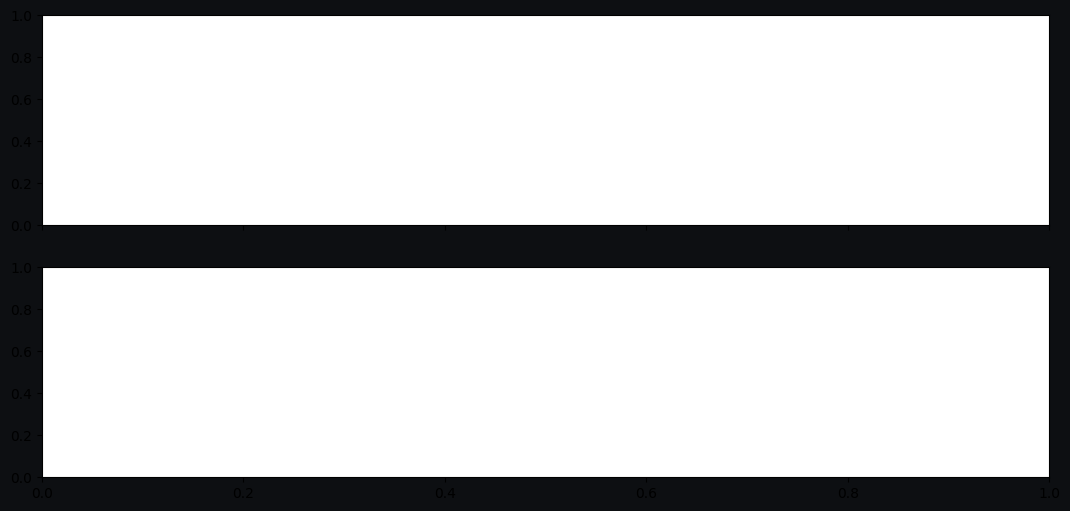

In [58]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
fig.patch.set_facecolor('#0d0f12') 

In [59]:
for ax in axes:
    ax.set_facecolor('#13161b')
    ax.tick_params(colors='#6b7585')
    ax.spines[:].set_color('#252a33') 

In [60]:
axes[0].plot(df['second'], df['latitude'], color='#3fd4a0', linewidth=1.8, marker='o',
             markersize=3, markerfacecolor='#3fd4a0') 

In [61]:
axes[0].fill_between(df['second'], df['latitude'], df['latitude'].min(),
                     alpha=0.12, color='#3fd4a0') 

In [62]:
axes[0].set_ylabel('Latitude (°N)', color='#6b7585', fontsize=10)
axes[0].set_title('GPS Track — Latitude & Longitude over Time',
                   color='white', fontsize=12, pad=10) 

Text(0.5, 1.0, 'GPS Track — Latitude & Longitude over Time')

In [63]:
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.5f'))
axes[0].grid(True, color='#252a33', linewidth=0.5) 

In [64]:
axes[1].plot(df['second'], df['longitude'], color='#4fc6f0', linewidth=1.8, marker='o',
             markersize=3, markerfacecolor='#4fc6f0')
axes[1].fill_between(df['second'], df['longitude'], df['longitude'].min(),
                     alpha=0.12, color='#4fc6f0')
axes[1].set_ylabel('Longitude (°E)', color='#6b7585', fontsize=10)
axes[1].set_xlabel('Time (seconds)', color='#6b7585', fontsize=10)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.5f'))
axes[1].grid(True, color='#252a33', linewidth=0.5) 

In [65]:
plt.tight_layout()
plt.savefig('gps_timeseries.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0f12')
plt.show()
print('✅ Saved: gps_timeseries.png') 

<Figure size 640x480 with 0 Axes>

✅ Saved: gps_timeseries.png


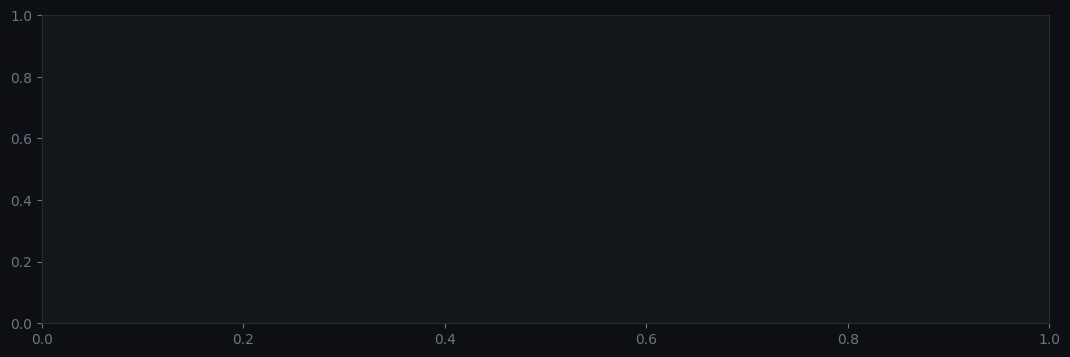

In [66]:
fig, ax = plt.subplots(figsize=(13, 4))
fig.patch.set_facecolor('#0d0f12')
ax.set_facecolor('#13161b')
ax.tick_params(colors='#6b7585')
ax.spines[:].set_color('#252a33') 

In [67]:
ax.plot(df['second'], df['cumulative_dist_m'],
        color='#f7c948', linewidth=2)
ax.fill_between(df['second'], df['cumulative_dist_m'],
                alpha=0.15, color='#f7c948') 

In [68]:
ax.annotate(f"{df['cumulative_dist_m'].iloc[-1]:.1f} m",
            xy=(df['second'].iloc[-1], df['cumulative_dist_m'].iloc[-1]),
            xytext=(-40, 12), textcoords='offset points',
            color='#f7c948', fontsize=10,
            arrowprops=dict(arrowstyle='->', color='#f7c948', lw=1)) 

Text(-40, 12, '540.7 m')

In [69]:
ax.set_xlabel('Time (seconds)', color='#6b7585', fontsize=10)
ax.set_ylabel('Distance (m)', color='#6b7585', fontsize=10)
ax.set_title('Cumulative Distance Travelled', color='white', fontsize=12, pad=10)
ax.grid(True, color='#252a33', linewidth=0.5) 

In [70]:
plt.tight_layout()
plt.savefig('gps_distance.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0f12')
plt.show()
print('✅ Saved: gps_distance.png') 

<Figure size 640x480 with 0 Axes>

✅ Saved: gps_distance.png


In [71]:
center_lat = df['latitude'].mean()
center_lon = df['longitude'].mean() 

In [72]:
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=16,
    tiles='OpenStreetMap'
) 

In [73]:
coords = list(zip(df['latitude'], df['longitude']))
folium.PolyLine(
    coords,
    color='#3fd4a0',
    weight=4,
    opacity=0.85,
    tooltip='GPS Track'
).add_to(m) 

In [74]:
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        color='#4fc6f0',
        weight=1.5,
        fill=True,
        fill_color='#0d0f12',
        fill_opacity=0.7,
        tooltip=(
            f"t={int(row['second'])}s | "
            f"Lat {row['latitude']}, Lon {row['longitude']} | "
            f"{row['datetime_IST']}"
        )
    ).add_to(m) 

In [75]:
folium.Marker(
    location=[df['latitude'].iloc[0], df['longitude'].iloc[0]],
    popup=folium.Popup(
        f"<b>START</b><br>Lat: {df['latitude'].iloc[0]}<br>"
        f"Lon: {df['longitude'].iloc[0]}<br>{df['datetime_IST'].iloc[0]}",
        max_width=200
    ),
    icon=folium.Icon(color='green', icon='play', prefix='fa')
).add_to(m) 

In [76]:
folium.Marker(
    location=[df['latitude'].iloc[-1], df['longitude'].iloc[-1]],
    popup=folium.Popup(
        f"<b>END</b><br>Lat: {df['latitude'].iloc[-1]}<br>"
        f"Lon: {df['longitude'].iloc[-1]}<br>{df['datetime_IST'].iloc[-1]}",
        max_width=200
    ),
    icon=folium.Icon(color='red', icon='stop', prefix='fa')
).add_to(m) 

In [77]:
m.save('gps_map.html')
print('✅ Saved: gps_map.html')
print('   Open in browser for full interactivity')

# Display inline in Jupyter
display(IFrame('gps_map.html', width='100%', height=500)) 

✅ Saved: gps_map.html
   Open in browser for full interactivity


In [78]:
total_m  = df['cumulative_dist_m'].iloc[-1]
avg_kmh  = (total_m / 1000 / len(df)) * 3600
ok_count = df_raw['latitude'].notna().sum()

print('=' * 50)
print('  GPS EXTRACTION SUMMARY')
print('=' * 50)
print(f'  Video          : {VIDEO_PATH}')
print(f'  Location       : Lucknow, UP, India')
print(f'  Date           : 20 May 2026')
print(f'  Start time     : {df["datetime_IST"].iloc[0]}')
print(f'  End time       : {df["datetime_IST"].iloc[-1]}')
print('-' * 50)
print(f'  Total points   : {len(df)}')
print(f'  OCR success    : {ok_count}/{len(df)} ({ok_count/len(df)*100:.0f}%)')
print(f'  Interpolated   : {len(df) - ok_count}')
print('-' * 50)
print(f'  Start lat/lon  : {df["latitude"].iloc[0]}, {df["longitude"].iloc[0]}')
print(f'  End   lat/lon  : {df["latitude"].iloc[-1]}, {df["longitude"].iloc[-1]}')
print(f'  Total distance : {total_m:.1f} m  ({total_m/1000:.3f} km)')
print(f'  Avg speed      : {avg_kmh:.1f} km/h')
print('=' * 50)
print()
print('Output files:')
for f in [OUTPUT_CSV, 'gps_map.html', 'gps_timeseries.png', 'gps_distance.png']:
    exists = '✅' if os.path.exists(f) else '❌'
    print(f'  {exists} {f}') 

  GPS EXTRACTION SUMMARY
  Video          : Eng_clg_60504PMByGPSMapCamera.mp4
  Location       : Lucknow, UP, India
  Date           : 20 May 2026
  Start time     : 20/05/2026 06:05:04 PM GMT +05:30
  End time       : 20/05/2026 06:06:13 PM GMT +05:30
--------------------------------------------------
  Total points   : 69
  OCR success    : 66/69 (96%)
  Interpolated   : 3
--------------------------------------------------
  Start lat/lon  : 26.913096, 80.939474
  End   lat/lon  : 26.916897, 80.937968
  Total distance : 540.7 m  (0.541 km)
  Avg speed      : 28.2 km/h

Output files:
  ✅ gps_track.csv
  ✅ gps_map.html
  ✅ gps_timeseries.png
  ✅ gps_distance.png


In [79]:
import shutil

# Uncomment the line below to delete temporary frames
# shutil.rmtree(FRAMES_DIR)

print(f'ℹ️  Temporary frames folder: {FRAMES_DIR}/')
frame_count = len([f for f in os.listdir(FRAMES_DIR) if f.endswith('.jpg')])
folder_size = sum(os.path.getsize(os.path.join(FRAMES_DIR, f))
                  for f in os.listdir(FRAMES_DIR) if f.endswith('.jpg')) / 1024
print(f'   Contains {frame_count} frames ({folder_size:.0f} KB)')
print()
print('To delete, uncomment the shutil.rmtree line above and re-run.') 

ℹ️  Temporary frames folder: frames_temp/
   Contains 69 frames (2015 KB)

To delete, uncomment the shutil.rmtree line above and re-run.
